<a href="https://colab.research.google.com/github/sathar1919/DS-Projects/blob/main/Customer_Churn_Prediction_%26_Retention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip -q install xgboost lightgbm catboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 9.9 MB/s eta 0:00:00


In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

import shap

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

df = pd.read_csv(url)

print(df.shape)

(7043, 21)


In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
#understand Data set
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

Dataset Shape:
(7043, 21)

Column Names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data Types:
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

Dataset Information

In [6]:
#Check missing values
missing = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df)) * 100
})

missing = missing.sort_values(
    "Missing Values",
    ascending=False
)

missing

,Column,Missing Values,Missing %
customerID,customerID,0,0.0
gender,gender,0,0.0
SeniorCitizen,SeniorCitizen,0,0.0
Partner,Partner,0,0.0
Dependents,Dependents,0,0.0
tenure,tenure,0,0.0
PhoneService,PhoneService,0,0.0
MultipleLines,MultipleLines,0,0.0
InternetService,InternetService,0,0.0
OnlineSecurity,OnlineSecurity,0,0.0


In [7]:
# Convert TotalCharges to numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [8]:
# Remove Customer ID
df.drop(columns=["customerID"],inplace=True)

In [9]:
# Convert target
df["Churn"] = df["Churn"].map({"Yes": 1,"No": 0})

In [10]:
# Remove missing target values
df.dropna(subset=["Churn"],inplace=True)

In [11]:
print("Cleaned dataset shape:", df.shape)

Cleaned dataset shape: (7043, 20)


In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


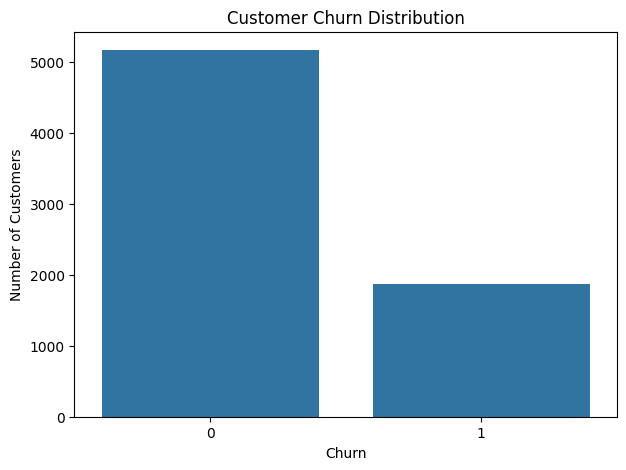

Churn
0    5174
1    1869
Name: count, dtype: int64

Percentage:
Churn
0    73.463013
1    26.536987
Name: proportion, dtype: float64


In [13]:
#Churn Distribution
plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="Churn"
)

plt.title("Customer Churn Distribution")

plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

print(
    df["Churn"]
    .value_counts()
)

print("\nPercentage:")

print(
    df["Churn"]
    .value_counts(normalize=True) * 100
)

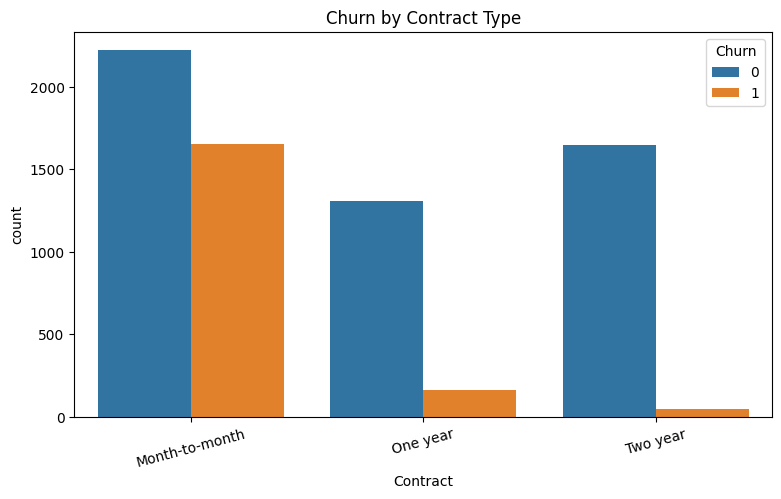

In [14]:
#Exploratory Data Analysis  --> Churn by contract
plt.figure(figsize=(9, 5))

sns.countplot(
    data=df,
    x="Contract",
    hue="Churn"
)

plt.title("Churn by Contract Type")

plt.xticks(rotation=15)

plt.show()


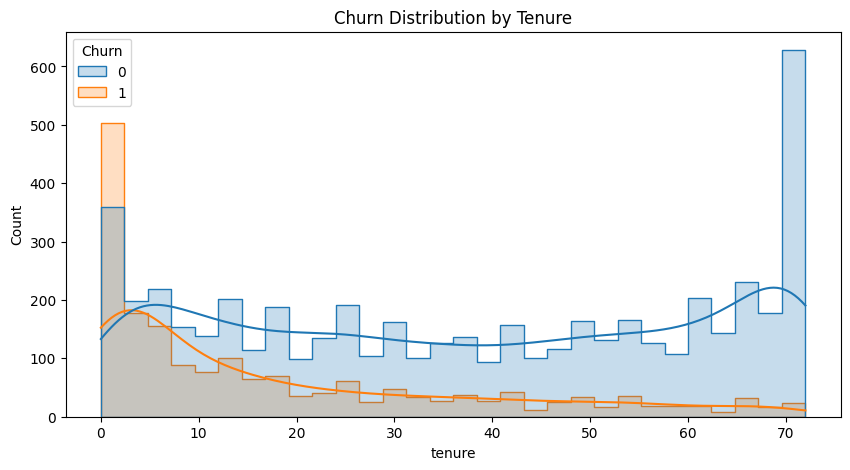

In [15]:
#churn by tenure
plt.figure(figsize=(10, 5))

sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True,
    element="step"
)

plt.title("Churn Distribution by Tenure")

plt.show()

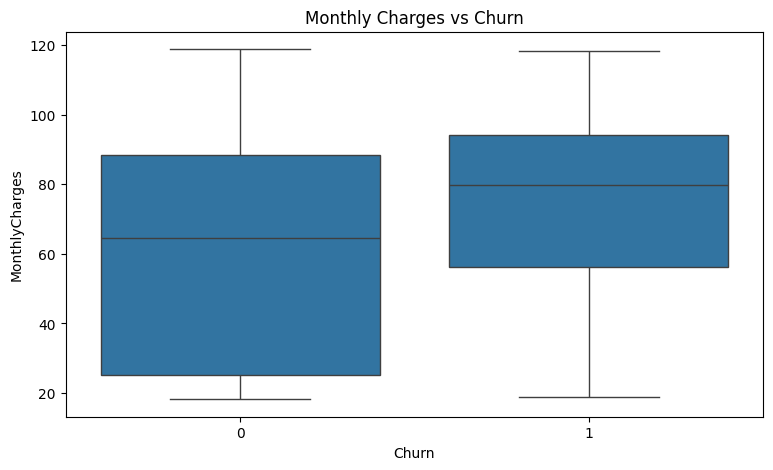

In [16]:
#Monthly charges vs churn
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)

plt.title("Monthly Charges vs Churn")

plt.show()

In [19]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7043, 19)
y shape: (7043,)


In [20]:
#Convert categorical variables
X = pd.get_dummies(X,drop_first=True)
print("After encoding:", X.shape)
X.head()

After encoding: (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [21]:
#Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42,
    stratify=y)
print("Training:", X_train.shape)
print("Testing :", X_test.shape)

Training: (5634, 30)
Testing : (1409, 30)


**Model Building**

We will compare four algorithms:

  Logistic Regression

  Random Forest

  Gradient Boosting

  XGBoost





In [24]:
#Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train,y_train)
lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:,1]

In [25]:
#Random Forest
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train,y_train)
rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:,1]

In [28]:
#Gradient Boosting
gb = GradientBoostingClassifier(n_estimators=200,learning_rate=0.05,max_depth=4,random_state=42)

gb.fit(X_train_imputed,y_train)
gb_pred = gb.predict(X_test_imputed)
gb_prob = gb.predict_proba(X_test_imputed)[:,1]

In [31]:
#XGBoost
xgb = XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,subsample=0.8,
    colsample_bytree=0.8,eval_metric="logloss",random_state=42 )

xgb.fit( X_train_imputed,y_train )

xgb_pred = xgb.predict(X_test_imputed)

xgb_prob = xgb.predict_proba(X_test_imputed)[:,1]

In [33]:
#Compare all models
results = []

models = {
    "Logistic Regression": (lr_pred, lr_prob),
    "Random Forest": (rf_pred, rf_prob),
    "Gradient Boosting": (gb_pred, gb_prob),
    "XGBoost": (xgb_pred, xgb_prob)
}


for name, (pred, prob) in models.items():
    results.append(
        { "Model": name,
         "Accuracy": accuracy_score(y_test, pred ),
        "Precision": precision_score(y_test, pred),"Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC-AUC": roc_auc_score(y_test, prob)
        }
        )
results_df = pd.DataFrame(results)
results_df.sort_values("ROC-AUC",ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Gradient Boosting,0.797019,0.647651,0.516043,0.574405,0.843172
0,Logistic Regression,0.803407,0.652997,0.553476,0.599132,0.842414
3,XGBoost,0.801278,0.659864,0.518717,0.580838,0.842215
1,Random Forest,0.793471,0.642612,0.500000,0.562406,0.827388


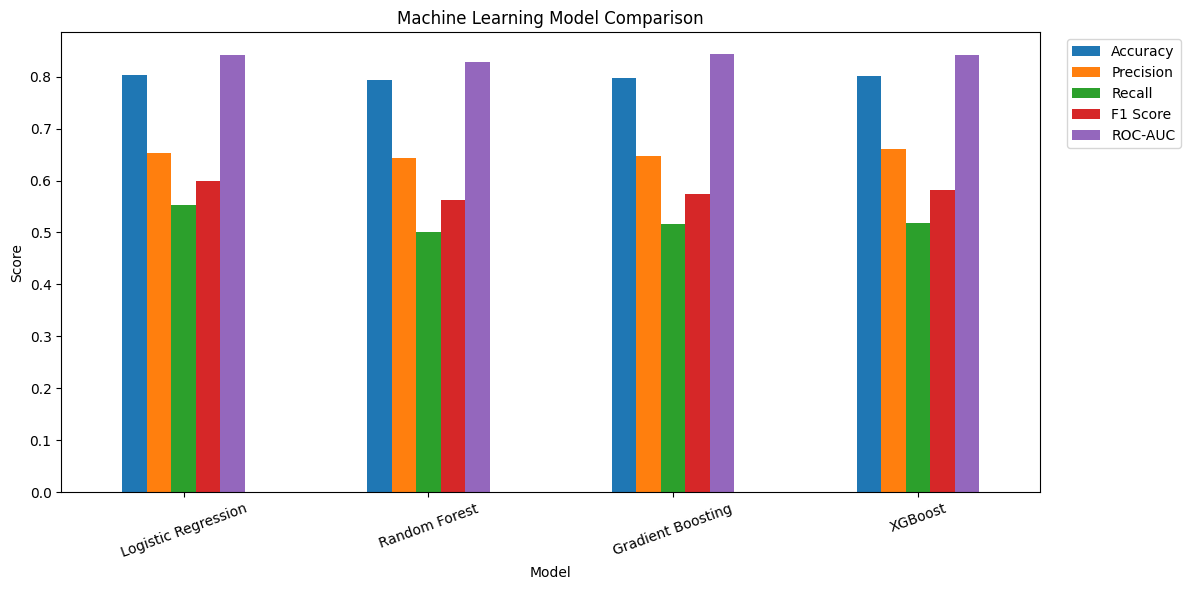

In [34]:
#Visualize model comparison
results_df.set_index("Model")[ ["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(kind="bar",figsize=(12,6))

plt.title("Machine Learning Model Comparison")

plt.ylabel("Score")

plt.xticks(rotation=20)

plt.legend(bbox_to_anchor=(1.02, 1),loc="upper left")

plt.tight_layout()

plt.show()

In [35]:
#select the best model
best_model_name = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Gradient Boosting


In [38]:
#Evaluate the Best Model
model_objects = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "XGBoost": xgb
}

best_model = model_objects[best_model_name]

best_prediction = best_model.predict(X_test_imputed)

best_probability = best_model.predict_proba(X_test_imputed)[:,1]

print(classification_report(y_test,best_prediction))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.65      0.52      0.57       374

    accuracy                           0.80      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



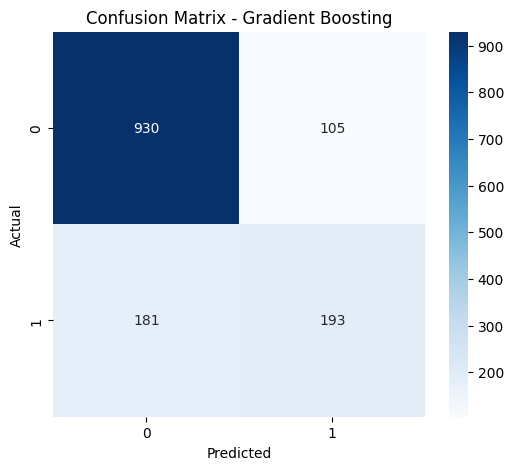

In [39]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    best_prediction
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel("Predicted")


plt.ylabel("Actual")


plt.title(
    "Confusion Matrix - " + best_model_name
)


plt.show()

In [40]:
#Feature Importance

#This is useful because you can explain why customers are leaving.

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})


importance = importance.sort_values(
    "Importance",
    ascending=False
)


importance.head(15)

,Feature,Importance
1,tenure,0.277137
10,InternetService_Fiber optic,0.182189
28,PaymentMethod_Electronic check,0.117264
3,TotalCharges,0.106418
2,MonthlyCharges,0.087190
25,Contract_Two year,0.044568
24,Contract_One year,0.041293
26,PaperlessBilling_Yes,0.022049
13,OnlineSecurity_Yes,0.017019
19,TechSupport_Yes,0.013921


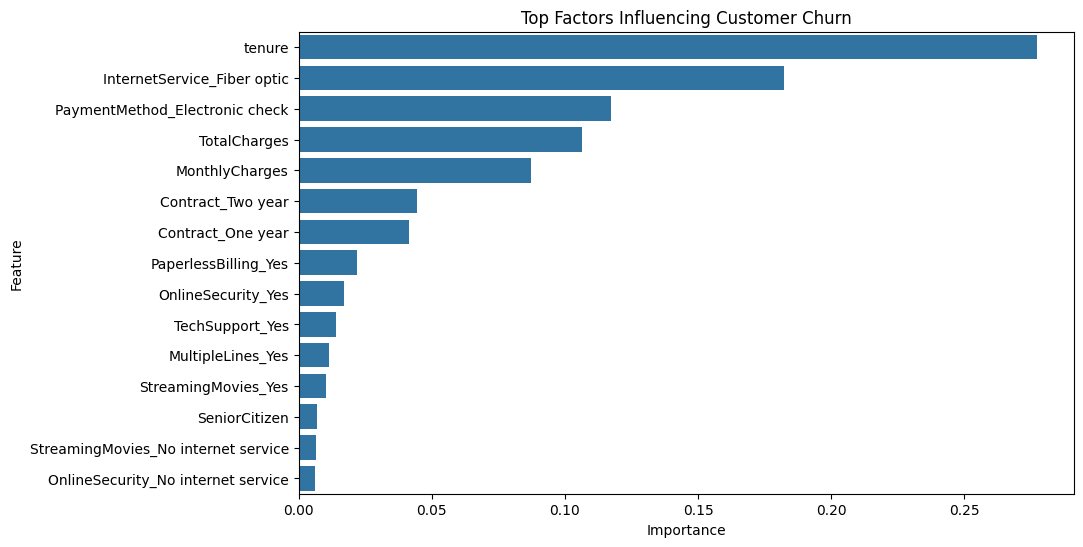

In [41]:
#Plot important features
plt.figure(figsize=(10,6))


sns.barplot(
    data=importance.head(15),
    x="Importance",
    y="Feature"
)


plt.title(
    "Top Factors Influencing Customer Churn"
)


plt.show()

In [42]:
#Customer Risk Prediction

#turn the ML model into a business solution.

customer_predictions = X_test.copy()

customer_predictions["Churn_Probability"] = ( best_probability)

customer_predictions["Actual_Churn"] = ( y_test.values)

customer_predictions.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability,Actual_Churn
437,0,72,114.05,8468.20,True,True,True,True,False,True,...,False,True,False,True,True,True,False,False,0.011645,0
2280,1,8,100.15,908.55,False,False,False,True,False,True,...,False,True,False,False,True,True,False,False,0.831848,0
2235,0,41,78.35,3211.20,False,True,True,True,False,True,...,False,False,True,False,True,True,False,False,0.053904,0
4460,0,18,78.20,1468.75,True,True,False,True,False,False,...,False,False,False,False,False,False,True,False,0.311863,0
3761,0,72,82.65,5919.35,False,True,False,True,False,True,...,False,True,False,True,True,True,False,False,0.014981,0


In [43]:
#Create risk categories
def risk_level(probability):

    if probability >= 0.70:
        return "High Risk"

    elif probability >= 0.40:
        return "Medium Risk"

    else:
        return "Low Risk"


customer_predictions["Risk_Level"] = (
    customer_predictions["Churn_Probability"]
    .apply(risk_level)
)

customer_predictions[
    [
        "Churn_Probability",
        "Risk_Level"
    ]
].head(20)

,Churn_Probability,Risk_Level
437,0.011645,Low Risk
2280,0.831848,High Risk
2235,0.053904,Low Risk
4460,0.311863,Low Risk
3761,0.014981,Low Risk
5748,0.628031,Medium Risk
3568,0.457832,Medium Risk
2976,0.104055,Low Risk
5928,0.014234,Low Risk
1639,0.344703,Low Risk


In [44]:
#Retention Strategy
def retention_strategy(row):

    probability = row["Churn_Probability"]

    if probability >= 0.70:

        return "Priority retention call + special offer"

    elif probability >= 0.40:

        return "Offer loyalty discount / upgrade"

    else:

        return "Normal customer engagement"


customer_predictions[
    "Retention_Strategy"
] = customer_predictions.apply(
    retention_strategy,
    axis=1
)

In [45]:
#Final customer list
final_results = customer_predictions[
    [
        "Churn_Probability",
        "Risk_Level",
        "Retention_Strategy"
    ]
].sort_values(
    "Churn_Probability",
    ascending=False
)

final_results.head(20)

,Churn_Probability,Risk_Level,Retention_Strategy
6866,0.927724,High Risk,Priority retention call + special offer
6623,0.926166,High Risk,Priority retention call + special offer
4585,0.925895,High Risk,Priority retention call + special offer
2464,0.924466,High Risk,Priority retention call + special offer
3380,0.913642,High Risk,Priority retention call + special offer
5826,0.905230,High Risk,Priority retention call + special offer
2194,0.904369,High Risk,Priority retention call + special offer
6748,0.901802,High Risk,Priority retention call + special offer
2631,0.899240,High Risk,Priority retention call + special offer
5300,0.898758,High Risk,Priority retention call + special offer


In [46]:
#High-risk customer count
print(customer_predictions["Risk_Level"].value_counts())

Risk_Level
Low Risk       1007
Medium Risk     280
High Risk       122
Name: count, dtype: int64


In [47]:
#Save the results
results_df.to_csv("model_comparison.csv",index=False)

final_results.to_csv("customer_retention_predictions.csv", index=False)

importance.to_csv("churn_feature_importance.csv",index=False)

print("Files saved successfully!")

Files saved successfully!


In [48]:
from google.colab import files

files.download("customer_retention_predictions.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>